In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

matches_path = "../data/matches_1930_2022.csv"
matches_df = pd.read_csv(matches_path)

matches_df

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1,NaN,NaN,0,NaN,NaN,Francisco Olazar,Manuel Ferreira,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
960,Yugoslavia,Brazil,2,NaN,NaN,1,NaN,NaN,Bosko Simonovic,Milutin Ivković,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
961,Romania,Peru,3,NaN,NaN,1,NaN,NaN,Octav Luchide,Emerich Vogl,...,NaN,NaN,NaN,Plácido Galindo · 70,NaN,NaN,NaN,NaN,NaN,NaN
962,United States,Belgium,3,NaN,NaN,0,NaN,NaN,Bob Millar,Tom Florie,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [39]:
ranking_path = "../data/fifa_ranking_2022-10-06.csv"
ranking_df = pd.read_csv(ranking_path)

ranking_df

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46
...,...,...,...,...,...,...,...
206,Sri Lanka,SRI,AFC,207,207,825.25,825.25
207,US Virgin Islands,VIR,CONCACAF,208,208,823.97,823.97
208,British Virgin Islands,VGB,CONCACAF,209,209,809.32,809.32
209,Anguilla,AIA,CONCACAF,210,210,790.74,790.74


In [40]:
team_ranking = ranking_df[[
    "team",
    "rank",
    "previous_rank"
]].copy()

team_ranking

,team,rank,previous_rank
0,Brazil,1,1
1,Belgium,2,2
2,Argentina,3,3
3,France,4,4
4,England,5,5
...,...,...,...
206,Sri Lanka,207,207
207,US Virgin Islands,208,208
208,British Virgin Islands,209,209
209,Anguilla,210,210


In [41]:
matches = matches_df[["home_team", "away_team", "Year", "home_score", "away_score", "Round", "home_penalty_shootout_goal_long", "away_penalty_shootout_goal_long"]].copy()
matches

,home_team,away_team,Year,home_score,away_score,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua..."
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN
...,...,...,...,...,...,...,...,...
959,Argentina,France,1930,1,0,Group stage,NaN,NaN
960,Yugoslavia,Brazil,1930,2,1,Group stage,NaN,NaN
961,Romania,Peru,1930,3,1,Group stage,NaN,NaN
962,United States,Belgium,1930,3,0,Group stage,NaN,NaN


In [42]:
home_matches = matches.copy()

home_matches = home_matches.rename(columns = {
    "home_team": "team",
    "away_team": "opponent",
    "Year": "year",
    "home_score": "goals_for",
    "away_score": "goals_against"
})

home_matches

,team,opponent,year,goals_for,goals_against,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua..."
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN
...,...,...,...,...,...,...,...,...
959,Argentina,France,1930,1,0,Group stage,NaN,NaN
960,Yugoslavia,Brazil,1930,2,1,Group stage,NaN,NaN
961,Romania,Peru,1930,3,1,Group stage,NaN,NaN
962,United States,Belgium,1930,3,0,Group stage,NaN,NaN


In [43]:
away_matches = matches.copy()

away_matches = away_matches.rename(columns = {
    "away_team": "team",
    "home_team": "opponent",
    "Year": "year",
    "away_score": "goals_for",
    "home_score": "goals_against"
})

away_matches

,opponent,team,year,goals_against,goals_for,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua..."
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN
...,...,...,...,...,...,...,...,...
959,Argentina,France,1930,1,0,Group stage,NaN,NaN
960,Yugoslavia,Brazil,1930,2,1,Group stage,NaN,NaN
961,Romania,Peru,1930,3,1,Group stage,NaN,NaN
962,United States,Belgium,1930,3,0,Group stage,NaN,NaN


In [44]:
def match_result(match):
    if match["goals_against"] < match["goals_for"]:
        return "W"
    elif match["goals_against"] == match["goals_for"]:
        return "D"
    else:
        return "L"


In [45]:
home_matches["result"] = home_matches.apply(match_result, axis=1)
away_matches["result"] = away_matches.apply(match_result, axis=1)

In [46]:
home_matches

,team,opponent,year,goals_for,goals_against,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,result
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",D
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN,W
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN,W
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN,W
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN,W
...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1930,1,0,Group stage,NaN,NaN,W
960,Yugoslavia,Brazil,1930,2,1,Group stage,NaN,NaN,W
961,Romania,Peru,1930,3,1,Group stage,NaN,NaN,W
962,United States,Belgium,1930,3,0,Group stage,NaN,NaN,W


In [47]:
away_matches

,opponent,team,year,goals_against,goals_for,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,result
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",D
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN,L
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN,L
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN,L
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN,L
...,...,...,...,...,...,...,...,...,...
959,Argentina,France,1930,1,0,Group stage,NaN,NaN,L
960,Yugoslavia,Brazil,1930,2,1,Group stage,NaN,NaN,L
961,Romania,Peru,1930,3,1,Group stage,NaN,NaN,L
962,United States,Belgium,1930,3,0,Group stage,NaN,NaN,L


In [48]:
team_matches = pd.concat([home_matches, away_matches])

team_matches

,team,opponent,year,goals_for,goals_against,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,result
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...",D
1,Croatia,Morocco,2022,2,1,Third-place match,NaN,NaN,W
2,France,Morocco,2022,2,0,Semi-finals,NaN,NaN,W
3,Argentina,Croatia,2022,3,0,Semi-finals,NaN,NaN,W
4,Morocco,Portugal,2022,1,0,Quarter-finals,NaN,NaN,W
...,...,...,...,...,...,...,...,...,...
959,France,Argentina,1930,0,1,Group stage,NaN,NaN,L
960,Brazil,Yugoslavia,1930,1,2,Group stage,NaN,NaN,L
961,Peru,Romania,1930,1,3,Group stage,NaN,NaN,L
962,Belgium,United States,1930,0,3,Group stage,NaN,NaN,L


In [49]:
team_summary = team_matches[[
    "year",
    "team", 
    "result",
    "goals_for",
    "goals_against"
]].copy()


team_summary["total_goal_difference"] = (
    team_summary["goals_for"]-team_summary["goals_against"]
)

team_summary

,year,team,result,goals_for,goals_against,total_goal_difference
0,2022,Argentina,D,3,3,0
1,2022,Croatia,W,2,1,1
2,2022,France,W,2,0,2
3,2022,Argentina,W,3,0,3
4,2022,Morocco,W,1,0,1
...,...,...,...,...,...,...
959,1930,France,L,0,1,-1
960,1930,Brazil,L,1,2,-1
961,1930,Peru,L,1,3,-2
962,1930,Belgium,L,0,3,-3


In [50]:
team_total = (
    team_summary
    .groupby(["year", "team", "result"])
    .size()
    .unstack(fill_value=0)
    .reset_index() 
)

team_total.head()

result,year,team,D,L,W
0,1930,Argentina,0,1,4
1,1930,Belgium,0,2,0
2,1930,Bolivia,0,2,0
3,1930,Brazil,0,1,1
4,1930,Chile,0,1,2


In [51]:
team_total["total_matches"] = (
    team_total["W"] + team_total["D"] + team_total["L"]
)

team_total["total_point"] = (
    team_total["W"]*3 + team_total["D"]*1 + team_total["L"]*0
)

team_total = team_total.rename(columns={
    "W": "win_matches",
    "D": "draw_matches",
    "L": "lost_matches"
})

team_total["point_per_match"] = (
    team_total["total_point"]/team_total["total_matches"]
)


team_total.head()

result,year,team,draw_matches,lost_matches,win_matches,total_matches,total_point,point_per_match
0,1930,Argentina,0,1,4,5,12,2.4
1,1930,Belgium,0,2,0,2,0,0.0
2,1930,Bolivia,0,2,0,2,0,0.0
3,1930,Brazil,0,1,1,2,3,1.5
4,1930,Chile,0,1,2,3,6,2.0


In [52]:
goals_summary = (
    team_summary
    .groupby(["year", "team"])
    .agg({
        "goals_for": "sum",
        "goals_against": "sum",
        "total_goal_difference": "sum"
    })
    .reset_index()
)

goals_summary

,year,team,goals_for,goals_against,total_goal_difference
0,1930,Argentina,18,9,9
1,1930,Belgium,0,4,-4
2,1930,Bolivia,0,8,-8
3,1930,Brazil,5,2,3
4,1930,Chile,5,3,2
...,...,...,...,...,...
484,2022,Switzerland,5,9,-4
485,2022,Tunisia,1,1,0
486,2022,United States,3,4,-1
487,2022,Uruguay,2,2,0


In [53]:
team_total = team_total.merge(
    goals_summary,
    on=["year", "team"],
    how="left"
)

team_total

,year,team,draw_matches,lost_matches,win_matches,total_matches,total_point,point_per_match,goals_for,goals_against,total_goal_difference
0,1930,Argentina,0,1,4,5,12,2.400000,18,9,9
1,1930,Belgium,0,2,0,2,0,0.000000,0,4,-4
2,1930,Bolivia,0,2,0,2,0,0.000000,0,8,-8
3,1930,Brazil,0,1,1,2,3,1.500000,5,2,3
4,1930,Chile,0,1,2,3,6,2.000000,5,3,2
...,...,...,...,...,...,...,...,...,...,...,...
484,2022,Switzerland,0,2,2,4,6,1.500000,5,9,-4
485,2022,Tunisia,1,1,1,3,4,1.333333,1,1,0
486,2022,United States,2,1,1,4,5,1.250000,3,4,-1
487,2022,Uruguay,1,1,1,3,4,1.333333,2,2,0


In [54]:
matches_final = matches[matches["Round"] == "Final"]

matches_final

,home_team,away_team,Year,home_score,away_score,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua..."
64,France,Croatia,2018,4,2,Final,NaN,NaN
128,Germany,Argentina,2014,1,0,Final,NaN,NaN
192,Netherlands,Spain,2010,0,1,Final,NaN,NaN
256,Italy,France,2006,1,1,Final,"['1|1:0|Andrea Pirlo', '3|2:1|Marco Materazzi'...","['2|1:1|Sylvain Wiltord', '6|3:2|Éric Abidal',..."
320,Germany,Brazil,2002,0,2,Final,NaN,NaN
384,Brazil,France,1998,0,3,Final,NaN,NaN
448,Brazil,Italy,1994,0,0,Final,"['4|1:1|Romário', '6|2:2|Branco', '8|3:2|Dunga']","['3|0:1|Demetrio Albertini', '5|1:2|Alberigo E..."
500,West Germany,Argentina,1990,1,0,Final,NaN,NaN
552,Argentina,West Germany,1986,3,2,Final,NaN,NaN


In [55]:
import ast
import pandas as pd


def parse_list_string(value):
    if pd.isna(value):
        return []

    if value == "":
        return []

    if isinstance(value, list):
        return value

    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

In [56]:
def get_penalty_summary(row):
    home_items = parse_list_string(row["home_penalty_shootout_goal_long"])
    away_items = parse_list_string(row["away_penalty_shootout_goal_long"])

    home_penalty = len(home_items)
    away_penalty = len(away_items)

    after_game_penalty = (home_penalty > 0) or (away_penalty > 0)

    if not after_game_penalty:
        penalty_winner = None
    elif home_penalty > away_penalty:
        penalty_winner = row["home_team"]
    elif away_penalty > home_penalty:
        penalty_winner = row["away_team"]
    else:
        penalty_winner = "DRAW"

    return pd.Series({
        "home_penalty_items": home_items,
        "away_penalty_items": away_items,
        "home_penalty": home_penalty,
        "away_penalty": away_penalty,
        "after_game_penalty": after_game_penalty,
        "penalty_winner": penalty_winner,
    })

In [57]:
penalty_summary = matches_final.apply(get_penalty_summary, axis=1)
penalty_summary

,home_penalty_items,away_penalty_items,home_penalty,away_penalty,after_game_penalty,penalty_winner
0,"[2|1:1|Lionel Messi, 4|2:1|Paulo Dybala, 6|3:1...","[1|0:1|Kylian Mbappé, 7|3:2|Randal Kolo Muani]",4,2,True,Argentina
64,[],[],0,0,False,NaN
128,[],[],0,0,False,NaN
192,[],[],0,0,False,NaN
256,"[1|1:0|Andrea Pirlo, 3|2:1|Marco Materazzi, 5|...","[2|1:1|Sylvain Wiltord, 6|3:2|Éric Abidal, 8|4...",5,3,True,Italy
320,[],[],0,0,False,NaN
384,[],[],0,0,False,NaN
448,"[4|1:1|Romário, 6|2:2|Branco, 8|3:2|Dunga]","[3|0:1|Demetrio Albertini, 5|1:2|Alberigo Evani]",3,2,True,Brazil
500,[],[],0,0,False,NaN
552,[],[],0,0,False,NaN


In [58]:
matches_final = pd.concat([matches_final, penalty_summary], axis=1)
matches_final

,home_team,away_team,Year,home_score,away_score,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_items,away_penalty_items,home_penalty,away_penalty,after_game_penalty,penalty_winner
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...","[2|1:1|Lionel Messi, 4|2:1|Paulo Dybala, 6|3:1...","[1|0:1|Kylian Mbappé, 7|3:2|Randal Kolo Muani]",4,2,True,Argentina
64,France,Croatia,2018,4,2,Final,NaN,NaN,[],[],0,0,False,NaN
128,Germany,Argentina,2014,1,0,Final,NaN,NaN,[],[],0,0,False,NaN
192,Netherlands,Spain,2010,0,1,Final,NaN,NaN,[],[],0,0,False,NaN
256,Italy,France,2006,1,1,Final,"['1|1:0|Andrea Pirlo', '3|2:1|Marco Materazzi'...","['2|1:1|Sylvain Wiltord', '6|3:2|Éric Abidal',...","[1|1:0|Andrea Pirlo, 3|2:1|Marco Materazzi, 5|...","[2|1:1|Sylvain Wiltord, 6|3:2|Éric Abidal, 8|4...",5,3,True,Italy
320,Germany,Brazil,2002,0,2,Final,NaN,NaN,[],[],0,0,False,NaN
384,Brazil,France,1998,0,3,Final,NaN,NaN,[],[],0,0,False,NaN
448,Brazil,Italy,1994,0,0,Final,"['4|1:1|Romário', '6|2:2|Branco', '8|3:2|Dunga']","['3|0:1|Demetrio Albertini', '5|1:2|Alberigo E...","[4|1:1|Romário, 6|2:2|Branco, 8|3:2|Dunga]","[3|0:1|Demetrio Albertini, 5|1:2|Alberigo Evani]",3,2,True,Brazil
500,West Germany,Argentina,1990,1,0,Final,NaN,NaN,[],[],0,0,False,NaN
552,Argentina,West Germany,1986,3,2,Final,NaN,NaN,[],[],0,0,False,NaN


In [59]:
def match_winner(match):
    if match["home_score"] > match["away_score"]:
        return match["home_team"]
    elif match["home_score"] < match["away_score"]:
        return match["away_team"]
    else:
        if match["home_penalty"] > match["away_penalty"]:
            return match["home_team"]
        elif match["home_penalty"] < match["away_penalty"]:
            return match["away_team"]


In [60]:
matches_final["winner"] = matches_final.apply(match_winner, axis=1)
matches_final

,home_team,away_team,Year,home_score,away_score,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long,home_penalty_items,away_penalty_items,home_penalty,away_penalty,after_game_penalty,penalty_winner,winner
0,Argentina,France,2022,3,3,Final,"['2|1:1|Lionel Messi', '4|2:1|Paulo Dybala', '...","['1|0:1|Kylian Mbappé', '7|3:2|Randal Kolo Mua...","[2|1:1|Lionel Messi, 4|2:1|Paulo Dybala, 6|3:1...","[1|0:1|Kylian Mbappé, 7|3:2|Randal Kolo Muani]",4,2,True,Argentina,Argentina
64,France,Croatia,2018,4,2,Final,NaN,NaN,[],[],0,0,False,NaN,France
128,Germany,Argentina,2014,1,0,Final,NaN,NaN,[],[],0,0,False,NaN,Germany
192,Netherlands,Spain,2010,0,1,Final,NaN,NaN,[],[],0,0,False,NaN,Spain
256,Italy,France,2006,1,1,Final,"['1|1:0|Andrea Pirlo', '3|2:1|Marco Materazzi'...","['2|1:1|Sylvain Wiltord', '6|3:2|Éric Abidal',...","[1|1:0|Andrea Pirlo, 3|2:1|Marco Materazzi, 5|...","[2|1:1|Sylvain Wiltord, 6|3:2|Éric Abidal, 8|4...",5,3,True,Italy,Italy
320,Germany,Brazil,2002,0,2,Final,NaN,NaN,[],[],0,0,False,NaN,Brazil
384,Brazil,France,1998,0,3,Final,NaN,NaN,[],[],0,0,False,NaN,France
448,Brazil,Italy,1994,0,0,Final,"['4|1:1|Romário', '6|2:2|Branco', '8|3:2|Dunga']","['3|0:1|Demetrio Albertini', '5|1:2|Alberigo E...","[4|1:1|Romário, 6|2:2|Branco, 8|3:2|Dunga]","[3|0:1|Demetrio Albertini, 5|1:2|Alberigo Evani]",3,2,True,Brazil,Brazil
500,West Germany,Argentina,1990,1,0,Final,NaN,NaN,[],[],0,0,False,NaN,West Germany
552,Argentina,West Germany,1986,3,2,Final,NaN,NaN,[],[],0,0,False,NaN,Argentina


In [61]:
matches_final_winner = matches_final[[
    "Year",
    "winner"
]].copy()

matches_final_winner = matches_final_winner.rename(columns={
    "Year": "year",
    "winner": "winner"
})

matches_final_winner

,year,winner
0,2022,Argentina
64,2018,France
128,2014,Germany
192,2010,Spain
256,2006,Italy
320,2002,Brazil
384,1998,France
448,1994,Brazil
500,1990,West Germany
552,1986,Argentina


In [62]:
matches_final_stage = matches[matches["Round"] == "Final stage"]

matches_final_stage

,home_team,away_team,Year,home_score,away_score,Round,home_penalty_shootout_goal_long,away_penalty_shootout_goal_long
889,Sweden,Spain,1950,3,1,Final stage,NaN,NaN
890,Uruguay,Brazil,1950,2,1,Final stage,NaN,NaN
891,Brazil,Spain,1950,6,1,Final stage,NaN,NaN
892,Uruguay,Sweden,1950,3,2,Final stage,NaN,NaN
893,Brazil,Sweden,1950,7,1,Final stage,NaN,NaN
894,Uruguay,Spain,1950,2,2,Final stage,NaN,NaN


In [63]:
home_final_stage_matches = matches_final_stage[[
    "home_team",
    "away_team",
    "Year",
    "home_score",
    "away_score"
]].copy()

home_final_stage_matches = home_final_stage_matches.rename(columns={
    "home_team": "team",
    "away_team": "opponent",
    "Year": "year",
    "home_score": "goals_for",
    "away_score": "goals_against"
})

home_final_stage_matches.head()

,team,opponent,year,goals_for,goals_against
889,Sweden,Spain,1950,3,1
890,Uruguay,Brazil,1950,2,1
891,Brazil,Spain,1950,6,1
892,Uruguay,Sweden,1950,3,2
893,Brazil,Sweden,1950,7,1


In [64]:
matches = matches_final_stage[["home_team", "away_team", "Year", "home_score", "away_score"]].copy()

away_final_stage_matches = matches_final_stage[[
    "home_team",
    "away_team",
    "Year",
    "home_score",
    "away_score"
]].copy()

away_final_stage_matches = away_final_stage_matches.rename(columns={
    "home_team": "opponent",
    "away_team": "team",
    "Year": "year",
    "home_score": "goals_against",
    "away_score": "goals_for"
})

away_final_stage_matches.head()

,opponent,team,year,goals_against,goals_for
889,Sweden,Spain,1950,3,1
890,Uruguay,Brazil,1950,2,1
891,Brazil,Spain,1950,6,1
892,Uruguay,Sweden,1950,3,2
893,Brazil,Sweden,1950,7,1


In [65]:
team_final_stage_matches = pd.concat([home_final_stage_matches, away_final_stage_matches], ignore_index=True)

team_final_stage_matches.head()

,team,opponent,year,goals_for,goals_against
0,Sweden,Spain,1950,3,1
1,Uruguay,Brazil,1950,2,1
2,Brazil,Spain,1950,6,1
3,Uruguay,Sweden,1950,3,2
4,Brazil,Sweden,1950,7,1


In [66]:
team_final_stage_matches["result"] = team_final_stage_matches.apply(match_result, axis=1)

team_final_stage_matches

,team,opponent,year,goals_for,goals_against,result
0,Sweden,Spain,1950,3,1,W
1,Uruguay,Brazil,1950,2,1,W
2,Brazil,Spain,1950,6,1,W
3,Uruguay,Sweden,1950,3,2,W
4,Brazil,Sweden,1950,7,1,W
5,Uruguay,Spain,1950,2,2,D
6,Spain,Sweden,1950,1,3,L
7,Brazil,Uruguay,1950,1,2,L
8,Spain,Brazil,1950,1,6,L
9,Sweden,Uruguay,1950,2,3,L


In [67]:
team_final_stage_summary = team_final_stage_matches[[
    "year",
    "team", 
    "result",
    "goals_for",
    "goals_against"
]].copy()

team_final_stage_total = (
    team_final_stage_summary
    .groupby(["year", "team", "result"])
    .size()
    .unstack(fill_value=0)
    .reset_index() 
)

team_final_stage_total["matches"] = (
    team_final_stage_total["W"] + team_final_stage_total["D"] + team_final_stage_total["L"]
)

team_final_stage_total["draw_rate"] = (
    team_final_stage_total["D"]/team_final_stage_total["matches"]
)

team_final_stage_total["lost_rate"] = (
    team_final_stage_total["L"]/team_final_stage_total["matches"]
)

team_final_stage_total["win_rate"] = (
    team_final_stage_total["W"]/team_final_stage_total["matches"]
)

team_final_stage_total["total_point"] = (
    team_final_stage_total["W"]*3 + team_final_stage_total["D"]*1 + team_final_stage_total["L"]*0
)

team_final_stage_total["point_per_match"] = (
    team_final_stage_total["total_point"]/team_final_stage_total["matches"]
)

team_final_stage_total = team_final_stage_total.sort_values("total_point", ascending=False)

team_final_stage_total.head()

result,year,team,D,L,W,matches,draw_rate,lost_rate,win_rate,total_point,point_per_match
3,1950,Uruguay,1,0,2,3,0.333333,0.000000,0.666667,7,2.333333
0,1950,Brazil,0,1,2,3,0.000000,0.333333,0.666667,6,2.000000
2,1950,Sweden,0,2,1,3,0.000000,0.666667,0.333333,3,1.000000
1,1950,Spain,1,2,0,3,0.333333,0.666667,0.000000,1,0.333333


In [68]:
final_stage_winner = (
    team_final_stage_total
    .sort_values(
        ["year", "total_point", "point_per_match", "win_rate"],
        ascending=[True, False, False, False]
    )
    .groupby("year")
    .head(1)
    [["year", "team"]]
    .rename(columns={
        "team": "winner"
    })
    .reset_index(drop=True)
)

final_stage_winner

result,year,winner
0,1950,Uruguay


In [69]:
matches_final_winner = pd.concat(
    [
        matches_final_winner,
        final_stage_winner
    ],
    ignore_index=True
)

matches_final_winner = (
    matches_final_winner
    .sort_values("year", ascending=False)
    .reset_index(drop=True)
)

matches_final_winner

,year,winner
0,2022,Argentina
1,2018,France
2,2014,Germany
3,2010,Spain
4,2006,Italy
5,2002,Brazil
6,1998,France
7,1994,Brazil
8,1990,West Germany
9,1986,Argentina


In [70]:
def is_winner(team):
    year = team["year"]
    team = team["team"]

    champion_row = matches_final_winner[
        matches_final_winner["year"] == year
    ]

    if champion_row.empty:
        return False

    champion = champion_row.iloc[0]["winner"]

    return team == champion

In [71]:
team_total["is_winner"] = team_total.apply(is_winner, axis=1)

team_total

,year,team,draw_matches,lost_matches,win_matches,total_matches,total_point,point_per_match,goals_for,goals_against,total_goal_difference,is_winner
0,1930,Argentina,0,1,4,5,12,2.400000,18,9,9,False
1,1930,Belgium,0,2,0,2,0,0.000000,0,4,-4,False
2,1930,Bolivia,0,2,0,2,0,0.000000,0,8,-8,False
3,1930,Brazil,0,1,1,2,3,1.500000,5,2,3,False
4,1930,Chile,0,1,2,3,6,2.000000,5,3,2,False
...,...,...,...,...,...,...,...,...,...,...,...,...
484,2022,Switzerland,0,2,2,4,6,1.500000,5,9,-4,False
485,2022,Tunisia,1,1,1,3,4,1.333333,1,1,0,False
486,2022,United States,2,1,1,4,5,1.250000,3,4,-1,False
487,2022,Uruguay,1,1,1,3,4,1.333333,2,2,0,False


In [72]:
champion_count = (
    matches_final_winner
    .groupby("winner")
    .size()
    .reset_index(name="champion_count")
    .sort_values("champion_count", ascending=False)
    .reset_index(drop=True)
)

champion_count

,winner,champion_count
0,Brazil,5
1,Italy,4
2,Argentina,3
3,France,2
4,Germany,2
5,Uruguay,2
6,West Germany,2
7,England,1
8,Spain,1


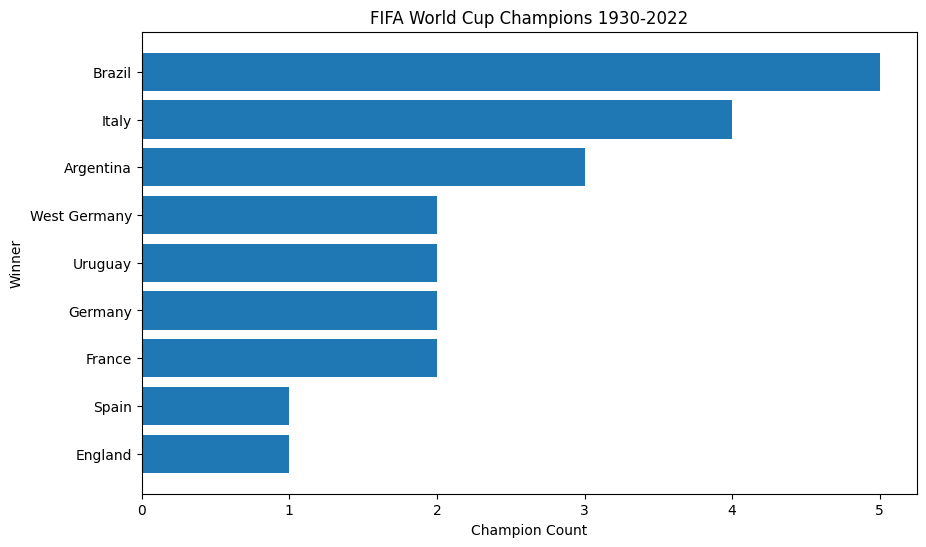

In [73]:
champion_count = champion_count.sort_values(
    "champion_count",
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    champion_count["winner"],
    champion_count["champion_count"]
)

plt.xlabel("Champion Count")
plt.ylabel("Winner")
plt.title("FIFA World Cup Champions 1930-2022")

plt.show()